--- Forecasting by Exponential Smoothing ---
Fetching 'flights' dataset...
Fitting the Exponential Smoothing Model...
Generating forecast...


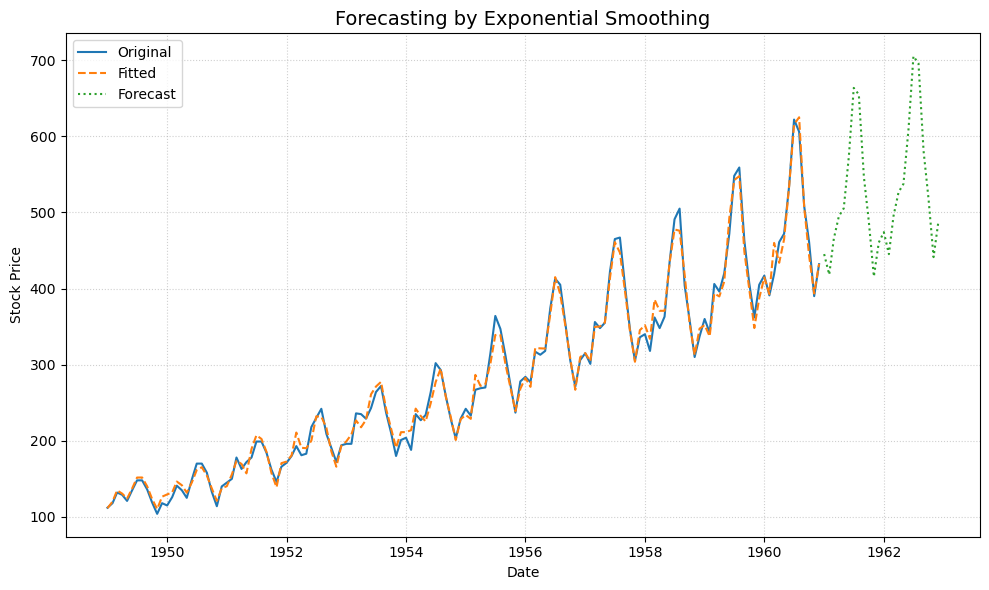


Forecasted Values:
1961-01-01    445.242402
1961-02-01    418.225352
1961-03-01    465.309707
1961-04-01    494.951212
1961-05-01    505.475849
1961-06-01    573.312582
1961-07-01    663.596287
1961-08-01    654.903933
1961-09-01    546.760954
1961-10-01    488.446890
1961-11-01    415.723594
1961-12-01    460.377969
1962-01-01    474.071211
1962-02-01    445.159517
1962-03-01    495.116191
1962-04-01    526.488104
1962-05-01    537.513230
1962-06-01    609.458585
1962-07-01    705.215797
1962-08-01    695.764716
1962-09-01    580.698026
1962-10-01    518.608440
1962-11-01    441.263066
1962-12-01    488.516673
Freq: MS, dtype: float64


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings

# Suppress harmless statsmodels warnings for a cleaner exam output
warnings.filterwarnings("ignore")

def exponential_smoothing_forecast():
   
    print("--- Forecasting by Exponential Smoothing ---")
    
    # 1. Load Dataset (Using Seaborn's 'flights' dataset for perfect seasonality)
    print("Fetching 'flights' dataset...")
    df = sns.load_dataset('flights')
    
    # The 'flights' dataset has 'year' and 'month' columns. 
    # We need to combine them into a proper Datetime index for statsmodels to work.
    df['Date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'].astype(str))
    df = df.sort_values(by='Date', ascending=True)
    df.set_index('Date', inplace=True)
    
    # We will use the 'passengers' column for our time series
    ts_data = df['passengers']

    print("Fitting the Exponential Smoothing Model...")
    
    # 2. Define the model
    # The flights data has a clear upward trend and a strong 12-month repeating season.
    # We use 'mul' (multiplicative) because the seasonal swings get wider as the years go on.
    model = ExponentialSmoothing(
        ts_data, 
        trend='add',
        seasonal='mul', 
        seasonal_periods=12 )
    
    # Fit the model
    fit = model.fit()

    print("Generating forecast...")
    
    # 3. Forecast future values
    # we have monthly data, let's forecast 24 months.
    forecast_steps = 24
    forecast = fit.forecast(steps=forecast_steps)

    # 4. Plot the results (Matching the Journal's exact style)
    plt.figure(figsize=(10, 6))
    
    # Plot Original Data (Solid Line)
    plt.plot(ts_data.index, ts_data, label='Original')
    
    # Plot Fitted Values (Orange Dashed Line)
    plt.plot(fit.fittedvalues.index, fit.fittedvalues, label='Fitted', linestyle='--')
    
    # Plot Forecast (Green Dashed Line)
    plt.plot(forecast.index, forecast, label='Forecast', linestyle=':')
    
    plt.title('Forecasting by Exponential Smoothing', fontsize=14)
    plt.xlabel('Date')
    plt.ylabel('Number of Passengers')
    plt.legend(loc='best')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

    # Print forecasted values
    print("\nForecasted Values:")
    print(forecast)

if __name__ == "__main__":
    exponential_smoothing_forecast()

# optional extra code 
### used before passing parameter values for algorithmic model like holtwinter above 

Fetching 'flights' dataset...
Generating plot...


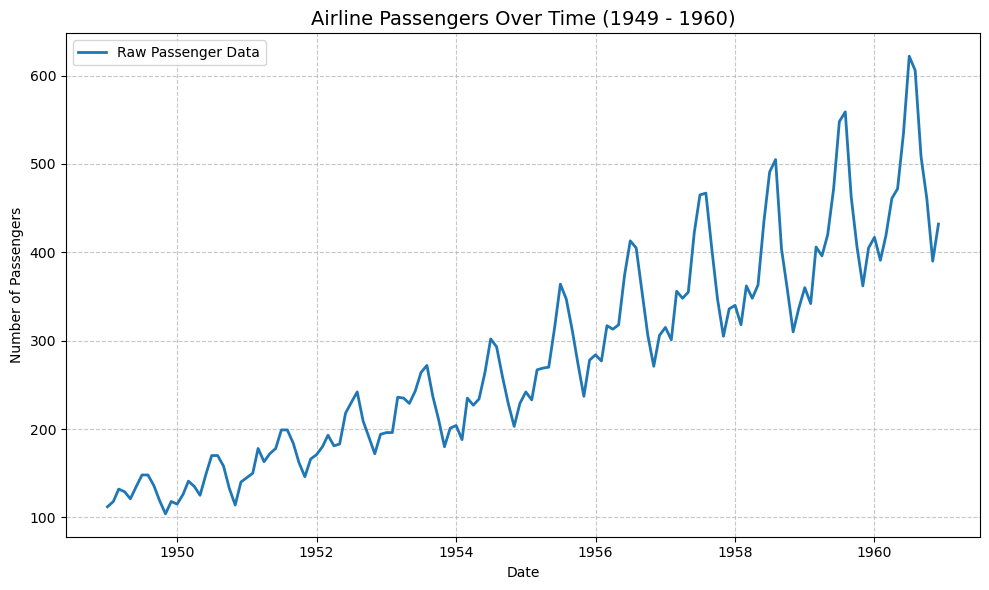

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Load and Prepare the Data ---
print("Fetching 'flights' dataset...")
df = sns.load_dataset('flights')

# Combine 'year' and 'month' into a single Datetime object
df['Date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'].astype(str))

# Sort chronologically and set the Date as the index
df = df.sort_values(by='Date', ascending=True)
df.set_index('Date', inplace=True)

# Isolate the specific column we want to plot
ts_data = df['passengers']

# --- 2. Plot the Raw Data ---
print("Generating plot...")
plt.figure(figsize=(10, 6))

# Plot the raw data as a solid blue line
plt.plot(ts_data.index, ts_data, label='Raw Passenger Data', color='tab:blue', linewidth=2)

# Add professional formatting
plt.title('Airline Passengers Over Time (1949 - 1960)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

# Display the graph
plt.tight_layout()
plt.show()